In [1]:
import os
import librosa # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
from sklearn.model_selection import train_test_split # type: ignore
from sklearn.preprocessing import LabelEncoder # type: ignore
from sklearn.metrics import accuracy_score, f1_score, classification_report , confusion_matrix, ConfusionMatrixDisplay # type: ignore
from sklearn.ensemble import GradientBoostingClassifier # type: ignore
from IPython.display import Audio # type: ignore
import seaborn as sns  # type: ignore
import pickle
import scipy # type: ignore
from scipy.signal import butter, lfilter # type: ignore
import noisereduce as nr # type: ignore
from scipy.io import wavfile # type: ignore
import datetime

/Users/panya/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

In [3]:
######### Data Pre-Processing ###########
# Set the path to dataset folder
print("#: Set the path to dataset folder")
data_dir = "/Users/panya/Project-ALL/DroneClassification/AcousticDroneDetection/dataset"

#: Set the path to dataset folder


In [4]:
# Load and preprocess audio data using spectrograms
#labels = os.listdir(data_dir)  # Read label form folder name 

labels = ['Drone','No_Drone']
audio_data = []
target_labels = []

# Sample rate and desired cutoff frequencies (in Hz).
order = 4
lowcut = 200.0
highcut = 1200.0

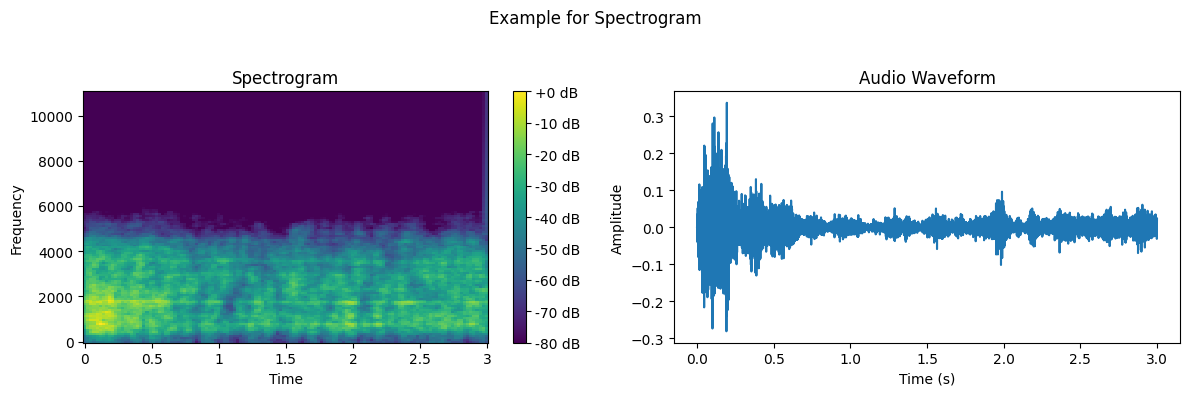

In [8]:
#Example to show spectrogram data 
audio_path = "./dataset/test/High20m_50m-3-ex6.wav"
#audio_path = "/Users/panya/Project-ALL/DroneClassification/AcousticDroneDetection/dataset/No_Drone/เสียงธรรมชาติ(สายสั้น)-ex8.wav"
audio_original, sample_rate = librosa.load(audio_path, duration=3)  # Load audio and limit to 3 seconds

# normalize audio  
max_value = np.max(np.abs(audio_original))       # Determine the maximum values
audio_normalize = audio_original/max_value        # Use max_value and normalize sound data to get values between -1 & +1

# band pass filter 
audio_BPF = butter_bandpass_filter(audio_normalize,lowcut,highcut,sample_rate,order=7)

# Noise reduce
Audio_Reduced_Noise = nr.reduce_noise(y=audio_BPF, sr=sample_rate,prop_decrease = 1)

# convert to spectrogram 
y = Audio_Reduced_Noise
spectrogram = librosa.feature.melspectrogram(y=y, sr=sample_rate)
spectrogram = librosa.power_to_db(spectrogram, ref=np.max)


plt.figure(figsize=(12, 4))
plt.suptitle(f'Example for Spectrogram')
plt.subplot(1, 2, 1)
plt.title(f'Spectrogram')
librosa.display.specshow(spectrogram, x_axis='time', y_axis='hz',cmap='viridis')  #cmap = 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
plt.colorbar(format='%+2.0f dB')
plt.xlabel('Time')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.title(f'Audio Waveform')
plt.plot(np.linspace(0, len(y) / sample_rate, len(y)), y)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [10]:
type(spectrogram)

numpy.ndarray

In [12]:
import xlsxwriter

workbook = xlsxwriter.Workbook('arrays.xlsx')
worksheet = workbook.add_worksheet()

row = 0

for col, data in enumerate(spectrogram):
    worksheet.write_column(row, col, data)

workbook.close()